# TensorFlow Neural Network for MNIST
In this notebook, we will build a neural network to classify handwritten digits from the MNIST dataset using TensorFlow.
We'll explore each step in creating, training, and evaluating the model.

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models
import numpy as np
import matplotlib.pyplot as plt


## Loading and Exploring the Dataset

Training data shape: (60000, 28, 28)
Test data shape: (10000, 28, 28)


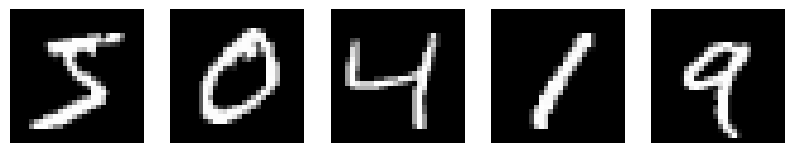

In [17]:
# Load the MNIST dataset from TensorFlow's datasets
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.mnist.load_data()

# Print dataset shapes
print('Training data shape:', x_train.shape)
print('Test data shape:', x_test.shape)

# Display a few samples
plt.figure(figsize=(10, 5))
for i in range(5):
    plt.subplot(1, 5, i + 1)
    plt.imshow(x_train[i], cmap='gray')
    plt.axis('off')
plt.show()

## Data Preprocessing

In [18]:
# Normalize pixel values (0-255) to (0-1) for faster and more efficient training
x_train, x_test = x_train / 255.0, x_test / 255.0

# One-hot encode labels for multi-class classification
y_train = tf.keras.utils.to_categorical(y_train, 10)
y_test = tf.keras.utils.to_categorical(y_test, 10)

## Building the Neural Network Model

In [ ]:
# Define a Sequential model with Dense layers
model = models.Sequential([
    layers.Flatten(input_shape=(28, 28)),
    
    layers.Dense(512, activation='relu'),  # Увеличил ширину слоя со 128 до 512
    layers.BatchNormalization(),           # Добавил слой нормализации предыдущего слоя
    layers.Dropout(0.3),                   # Добавил слой регуляризации для отключения 30% нейронов
    
    layers.Dense(256, activation='relu'),  # Увеличил ширину слоя с 64 до 256
    layers.BatchNormalization(),
    layers.Dropout(0.3), 
    
    layers.Dense(128, activation='relu'),  # Доп.слой
    layers.BatchNormalization(),
    layers.Dropout(0.2),                   # Добавил слой регуляризации для отключения 20% нейронов
    
    layers.Dense(10, activation='softmax') # Доп.слой
])
model.summary()

/Users/nikitabaslykov/Documents/Python/ML - University/Без названия/SAI-Course/venv/lib/python3.12/site-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │       401,920 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 571,018 (2.18 MB)

 Trainable params: 569,226 (2.17 MB)

 Non-trainable params: 1,792 (7.00 KB)

## Compiling the Model

In [20]:
# Compile the model with an optimizer, loss function, and evaluation metric
model.compile(optimizer='adam',                     # Adam optimizer for adaptive learning rate
              loss='categorical_crossentropy',      # Cross-entropy for multi-class classification
              metrics=['accuracy'])                 # Track accuracy during training

## Training the Model

In [21]:
# Train the model and store training history for visualization
history = model.fit(x_train, y_train, epochs=10, 
                    validation_split=0.2,           # Use 20% of the training data for validation
                    batch_size=32)                  # Process data in batches of 32

Epoch 1/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8940 - loss: 0.3435 - val_accuracy: 0.9531 - val_loss: 0.1509
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9410 - loss: 0.1940 - val_accuracy: 0.9674 - val_loss: 0.1051
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9495 - loss: 0.1634 - val_accuracy: 0.9700 - val_loss: 0.0957
Epoch 4/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9569 - loss: 0.1393 - val_accuracy: 0.9755 - val_loss: 0.0828
Epoch 5/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9609 - loss: 0.1239 - val_accuracy: 0.9757 - val_loss: 0.0797
Epoch 6/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9642 - loss: 0.1149 - val_accuracy: 0.9778 - val_loss: 0.0724
Epoch 7/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9672 - loss: 0.1037 - val_accuracy: 0.9757 - val_loss: 0.0762
Epoch 8/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9692 - loss: 0.0977 - 

## Evaluating the Model

In [22]:
# Evaluate on the test dataset
test_loss, test_accuracy = model.evaluate(x_test, y_test, verbose=0)
print(f'Test Accuracy: {test_accuracy:.4f}')
print(f'Test Loss: {test_loss:.4f}')

Test Accuracy: 0.9796
Test Loss: 0.0660


## Visualizing Results

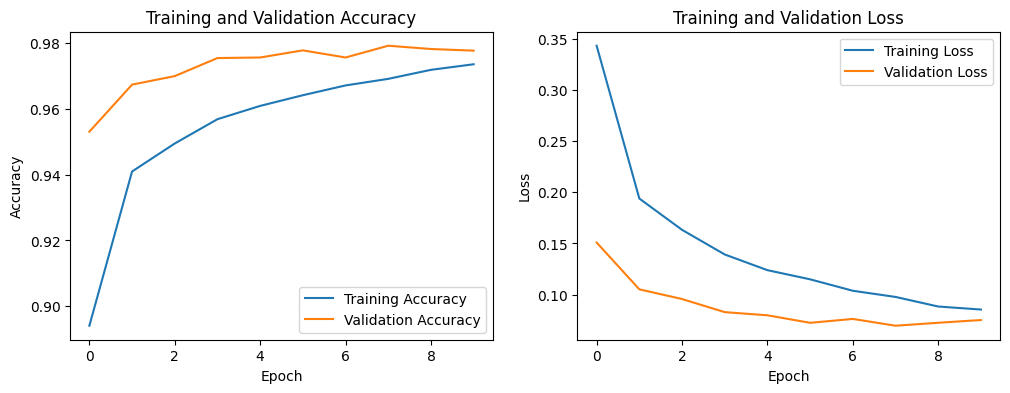

In [23]:
# Plotting training and validation accuracy over epochs
plt.figure(figsize=(12, 4))

# Accuracy Plot
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.title('Training and Validation Accuracy')

# Loss Plot
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.title('Training and Validation Loss')

plt.show()

## Predicting and Visualizing Sample Predictions

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


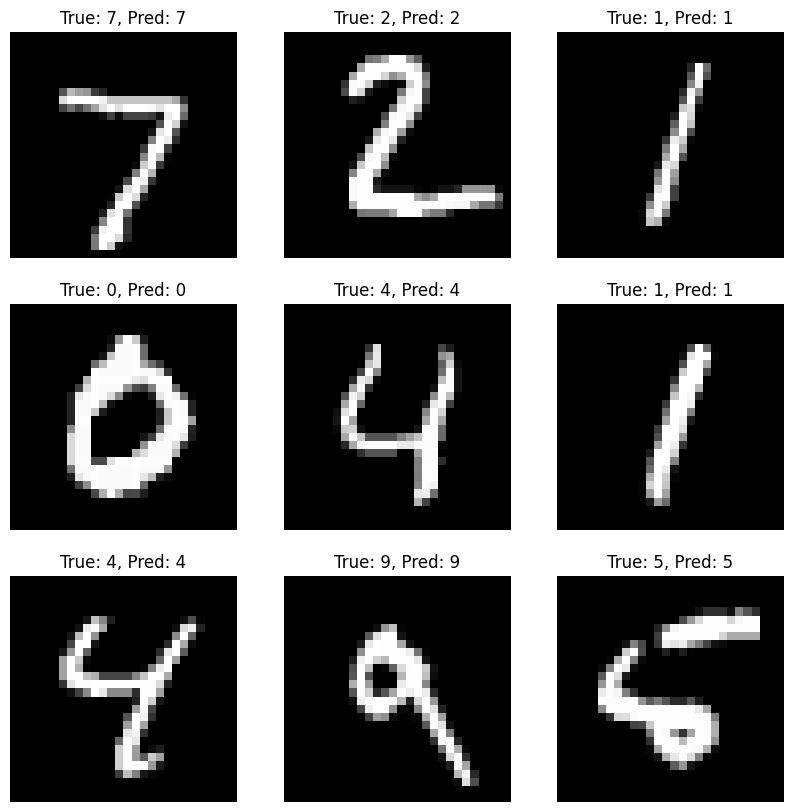

In [9]:
# Make predictions
predictions = model.predict(x_test)
predicted_labels = np.argmax(predictions, axis=1)
true_labels = np.argmax(y_test, axis=1)

# Visualize a few predictions along with true labels
plt.figure(figsize=(10, 10))
for i in range(9):
    plt.subplot(3, 3, i + 1)
    plt.imshow(x_test[i], cmap='gray')
    plt.title(f'True: {true_labels[i]}, Pred: {predicted_labels[i]}')
    plt.axis('off')
plt.show()

## What's next?

Try experimenting with parameters, improve model accuracy, increase the number of epochs, apply early stopping

**Happy training! 🎉**